# UBDS 2026: Basic Python
## Day 5: Machine learning and data science


### Topics covered / Сьогоднішні теми
1. Basic exploratory data analysis (EDA) / Першопочаткове дослідження данних
2. Correlation / Кореляція 
3. t-test / Тест Стьюдента
4. One-way ANOVA / Дисперсійний аналіз
5. Simple linear regression / Лінійна регресія
6. microProject/RF / Мікропроект/метод випадкового лісу 


We will use the palmers penguins dataset (`palmerpenguins_extended.csv`) which contains characteristics of penguins population over the years:
Будемо використовувати набір даних про пінгвінів Палмера(`palmerpenguins_extended.csv`), що містить характеристики популяції цих пінгвінів впродовж кількох років: 

- `species` / `вид`
- `island` / `острів`
- `bill_length_mm` / `довжина клюву`
- `bill_depth_mm` / `глибина клюву`
- `flipper_length_mm` `довжина плавців`
- `body_mass_g` / `маса тіла`
- `sex` / `стать`
- `diet` / `дєта`
- `life_stage` / `стадія життя`
- `health_metrics` / `здоров'я`
- `year` / `рік`


# Import the tools we need

- `pandas` helps us work with tables of data / для роботи з таблицями
- `numpy` is needed to work with numerical data / для роботи з числовими данними
- `matplotlib` helps us make plots / для графіків
- `scipy.stats` gives us statistical tests / для статистичних тестів
- `statsmodels` gives us additional statistical tests / для додаткових тестів
- `LinearRegression` from `sklearn` helps us build a simple regression model / для лінійної регресії
- `PolynomialFeatures` from sklearn gives us  way to build polynomial models

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [107]:
from importlib.metadata import version
print(version('seaborn'))

0.12.2


# Load the dataset

Note - be sure that file actually exist at the given location / Переконайтеся що вказаний шлях є вірним

Common name for a dataframe - df. / Типове ім'я для датафрейму ДФ.

In [2]:
df = pd.read_csv("palmerpenguins_extended.csv")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
0,Adelie,Biscoe,53.4,NaN,219.0,5687.0,female,fish,adult,overweight,2021
1,Adelie,Biscoe,49.3,18.1,NaN,6811.0,female,fish,adult,overweight,2021
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,female,fish,juvenile,overweight,2021
...,...,...,...,...,...,...,...,...,...,...,...
3425,Gentoo,Biscoe,44.0,20.4,252.0,6447.0,male,squid,adult,healthy,2025
3426,Gentoo,Biscoe,54.5,25.2,245.0,6872.0,male,squid,adult,healthy,2025
3427,Gentoo,Biscoe,51.4,20.4,258.0,7409.0,male,squid,adult,overweight,2025
3428,Gentoo,Biscoe,55.9,20.5,247.0,6491.0,male,squid,adult,healthy,2025


# First look at the data

To repeat previous lesson - please print: / Для закріплення вчорашнього дня - будь ласка визначте 
- the first few rows / Перші кілька строчок  
- the last few rows / Останні кілька строчок 
- the shape of the table / Форма таблиці 
- the column names / Імена колонок
- the data types in each column / Типи даних в колонках
- rows number 5 and 10 / строчки номер 5 і 10
- flipper length column / колонку що містить довжину плавців

In [3]:
#your code goes here
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
0,Adelie,Biscoe,53.4,NaN,219.0,5687.0,female,fish,adult,overweight,2021
1,Adelie,Biscoe,49.3,18.1,NaN,6811.0,female,fish,adult,overweight,2021
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,female,fish,juvenile,overweight,2021


In [4]:
#your code goes here
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
3425,Gentoo,Biscoe,44.0,20.4,252.0,6447.0,male,squid,adult,healthy,2025
3426,Gentoo,Biscoe,54.5,25.2,245.0,6872.0,male,squid,adult,healthy,2025
3427,Gentoo,Biscoe,51.4,20.4,258.0,7409.0,male,squid,adult,overweight,2025
3428,Gentoo,Biscoe,55.9,20.5,247.0,6491.0,male,squid,adult,healthy,2025
3429,Gentoo,Biscoe,43.9,22.9,206.0,6835.0,male,squid,adult,healthy,2025


In [5]:
#your code goes here
df.shape

(3430, 11)

In [6]:
#your code goes here
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'diet', 'life_stage',
       'health_metrics', 'year'],
      dtype='object')

In [7]:
#your code goes here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3430 entries, 0 to 3429
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            3430 non-null   object 
 1   island             3430 non-null   object 
 2   bill_length_mm     3420 non-null   float64
 3   bill_depth_mm      3293 non-null   float64
 4   flipper_length_mm  3190 non-null   float64
 5   body_mass_g        3327 non-null   float64
 6   sex                3389 non-null   object 
 7   diet               3430 non-null   object 
 8   life_stage         3430 non-null   object 
 9   health_metrics     3430 non-null   object 
 10  year               3430 non-null   int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 294.9+ KB


In [8]:
#your code goes here
df.loc[[5, 10]]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
5,Adelie,Biscoe,35.7,16.8,194.0,5266.0,female,fish,juvenile,overweight,2021
10,Adelie,Biscoe,63.9,16.5,277.0,6147.0,male,fish,adult,overweight,2021


In [9]:
#your code goes here
df["flipper_length_mm"]

0       219.0
1         NaN
2       226.0
3       221.0
4       177.0
        ...  
3425    252.0
3426    245.0
3427    258.0
3428    247.0
3429    206.0
Name: flipper_length_mm, Length: 3430, dtype: float64

# Missing values

A missing value is called NA(NA-Not assesed) and it means some information is absent / Відсутнє значення називають NA, і це значить що частина інформації відсутня.

We can count missing values in each column like this / Ми можемо порахувати відсутні значення наступним чином.

In [10]:
df.isna().sum()

species                0
island                 0
bill_length_mm        10
bill_depth_mm        137
flipper_length_mm    240
body_mass_g          103
sex                   41
diet                   0
life_stage             0
health_metrics         0
year                   0
dtype: int64

We have two strategies how to deal with NA. First one is simply removing them. / У нас є дві стратегії як розбиратися з NA. Перший варіант просто їх прибрати.

In [11]:
df_drop = df.dropna()
df_drop.shape

(2930, 11)

In [12]:
df_drop.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
diet                 0
life_stage           0
health_metrics       0
year                 0
dtype: int64

Second option is to impute them using mean or median / Наступний варіант це заповнити їх використовуючи середнє чи медіану

In [13]:
df_fill = df.copy()

df_fill["body_mass_g"] = df_fill["body_mass_g"].fillna(
    df_fill["body_mass_g"].mean()
)

df_fill["flipper_length_mm"] = df_fill["flipper_length_mm"].fillna(
    df_fill["flipper_length_mm"].median()
)

#inpute lenght of bil with mean and depth of bill with median / зааповніть довжину клюва середнім значенням і глибину клюва медіаною

#

df_fill.isna().sum()

species                0
island                 0
bill_length_mm        10
bill_depth_mm        137
flipper_length_mm      0
body_mass_g            0
sex                   41
diet                   0
life_stage             0
health_metrics         0
year                   0
dtype: int64

In [14]:
df=df.dropna()

# Looking at categories

Some columns contain categories, not numbers. / В деяких колонках маємо категорії а не числа

Examples:
- species
- island
- sex
- diet
- life_stage
- health_metrics


In [15]:
df["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [16]:
df["island"].unique()

array(['Biscoe', 'Dream', 'Torgensen'], dtype=object)

In [17]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [18]:
df["life_stage"].unique()

array(['adult', 'juvenile', 'chick'], dtype=object)

In [19]:
df["health_metrics"].unique()

array(['overweight', 'healthy', 'underweight'], dtype=object)

## Solution to Exercise 2

1. There are **3 species**
2. There are **3 islands**
3. There are **2 sexes**
4. The life stages are **adult, juvenile, chick**

# Basic descriptive statistics

Descriptive statistics help us summarize numeric variables.  / Описова статистика допомогає нам дослідити числові значення.

Typical examples:
- mean
- standard deviation
- minimum
- maximum
- quartiles

We can get using one function / Для цього у нас є одна проста функція

In [20]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,38.460137,18.422457,206.862799,4825.317747,2023.357338
std,13.181151,2.771981,28.868658,1312.744023,1.315255
min,13.600000,9.700000,140.000000,2508.000000,2021.000000
25%,28.800000,16.600000,185.000000,3845.000000,2022.000000
50%,34.450000,18.400000,203.000000,4618.500000,2024.000000
75%,46.500000,20.300000,225.000000,5594.000000,2024.000000
max,88.200000,27.900000,308.000000,10549.000000,2025.000000


## Focus on one variable

We can also inspect one column at a time. / Також ми можемо отримати таку статистику для однієї колонки

In [21]:
df["body_mass_g"].describe()

count     2930.000000
mean      4825.317747
std       1312.744023
min       2508.000000
25%       3845.000000
50%       4618.500000
75%       5594.000000
max      10549.000000
Name: body_mass_g, dtype: float64

# Simple filtering

Filtering means selecting only the rows we want / Фільтрування обирає тільки ті строчки що відповідають певній умові

For repetition filter:
- only Adelie penguins
- only adult penguins
- only male penguins
- only penguins from Biscoe island and male:

In [22]:
#your code goes here
adelie = df[df["species"] == "Adelie"]
adelie

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
4,Adelie,Biscoe,60.7,17.9,177.0,4811.0,female,fish,juvenile,overweight,2021
5,Adelie,Biscoe,35.7,16.8,194.0,5266.0,female,fish,juvenile,overweight,2021
6,Adelie,Biscoe,61.0,20.8,211.0,5961.0,female,fish,adult,overweight,2021
...,...,...,...,...,...,...,...,...,...,...,...
2960,Adelie,Torgensen,31.0,16.3,167.0,3604.0,male,parental,chick,healthy,2025
2961,Adelie,Torgensen,31.5,14.8,166.0,3495.0,male,parental,chick,healthy,2025
2962,Adelie,Torgensen,33.4,19.0,175.0,4225.0,female,squid,juvenile,healthy,2025
2963,Adelie,Torgensen,40.7,18.1,198.0,5049.0,female,squid,adult,overweight,2025


In [23]:
#your code goes here
adult = df[df["life_stage"] == "adult"]
adult.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
2,Adelie,Biscoe,55.7,16.6,226.0,5388.0,female,fish,adult,overweight,2021
3,Adelie,Biscoe,38.0,15.6,221.0,6262.0,female,fish,adult,overweight,2021
6,Adelie,Biscoe,61.0,20.8,211.0,5961.0,female,fish,adult,overweight,2021
7,Adelie,Biscoe,66.1,20.8,246.0,6653.0,male,fish,adult,overweight,2021
8,Adelie,Biscoe,61.4,19.9,270.0,6722.0,male,fish,adult,overweight,2021


In [24]:
#your code goes here
males = df[(df["life_stage"] == "adult") & (df["sex"] == "male")]
males.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
7,Adelie,Biscoe,66.1,20.8,246.0,6653.0,male,fish,adult,overweight,2021
8,Adelie,Biscoe,61.4,19.9,270.0,6722.0,male,fish,adult,overweight,2021
10,Adelie,Biscoe,63.9,16.5,277.0,6147.0,male,fish,adult,overweight,2021
12,Adelie,Biscoe,57.4,19.5,255.0,5920.0,male,fish,adult,healthy,2021
20,Adelie,Biscoe,31.7,24.6,216.0,4821.0,male,krill,adult,underweight,2021


In [25]:
#your code goes here
bisc_males = df[(df["island"] == "Biscoe") & (df["sex"] == "male")]
bisc_males.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
7,Adelie,Biscoe,66.1,20.8,246.0,6653.0,male,fish,adult,overweight,2021
8,Adelie,Biscoe,61.4,19.9,270.0,6722.0,male,fish,adult,overweight,2021
10,Adelie,Biscoe,63.9,16.5,277.0,6147.0,male,fish,adult,overweight,2021
12,Adelie,Biscoe,57.4,19.5,255.0,5920.0,male,fish,adult,healthy,2021
19,Adelie,Biscoe,31.6,16.0,214.0,5004.0,male,krill,juvenile,healthy,2021


# Counting categories

To work with categories we can count them. / Аби працювати з категоріями ми можемо їх порахувати

For that we use `value_counts()`.

In [26]:
df["species"].value_counts()

Adelie       1334
Gentoo       1063
Chinstrap     533
Name: species, dtype: int64

## Relative frequencies

Sometimes we want percentages instead of raw counts. / Інколи ми хочемо оперувати не сирими значеннями, а частотами

We can do that with `normalize=True`.

In [27]:
df["species"].value_counts(normalize=True)

Adelie       0.455290
Gentoo       0.362799
Chinstrap    0.181911
Name: species, dtype: float64

# Group summaries

Group summaries are used to count group-wise statistics. / Групування використовується аби рахувати погрупову статистику.

As a reminder lets calculate / Як нагадування давайте порахуємо
- What is the average body mass for each species? / Середю вагу для різних видів
- What is the avrage flipper length for each island? / Середню довжину плавців на різних островах
- What is the median bill length for males and females? / Медіанну довжини клюва серед різних статей
- What is the frequencies of different species occurence on each island/  Якою є частота різних видів на кожному острові

The general pattern is:
`df.groupby("group_column")["numeric_column"].mean()`

In [28]:
df.groupby("species")["body_mass_g"].mean()

species
Adelie       4409.663418
Chinstrap    4613.236398
Gentoo       5453.278457
Name: body_mass_g, dtype: float64

In [29]:
#your code goes here
df.groupby("species")["flipper_length_mm"].mean()

species
Adelie       200.091454
Chinstrap    202.529081
Gentoo       217.533396
Name: flipper_length_mm, dtype: float64

In [30]:
#your code goes here
df.groupby("sex")["body_mass_g"].median()

sex
female    4249.0
male      5015.0
Name: body_mass_g, dtype: float64

In [31]:
#your code goes here
df.groupby("island")["species"].value_counts(normalize=True)

island     species  
Biscoe     Gentoo       0.703042
           Adelie       0.296958
Dream      Chinstrap    0.543878
           Adelie       0.456122
Torgensen  Adelie       1.000000
Name: species, dtype: float64

## Group by more than one column

We can also group by two variables. Також можна групувати по двом або більше колонкам

In [32]:
df.groupby(["species", "sex"])["body_mass_g"].mean()

species    sex   
Adelie     female    4074.150289
           male      4771.306854
Chinstrap  female    4235.328720
           male      5060.840164
Gentoo     female    4913.241107
           male      5943.868941
Name: body_mass_g, dtype: float64

## Histogram

A histogram shows the distribution of one numeric variable.

Here we plot `body_mass_g`.

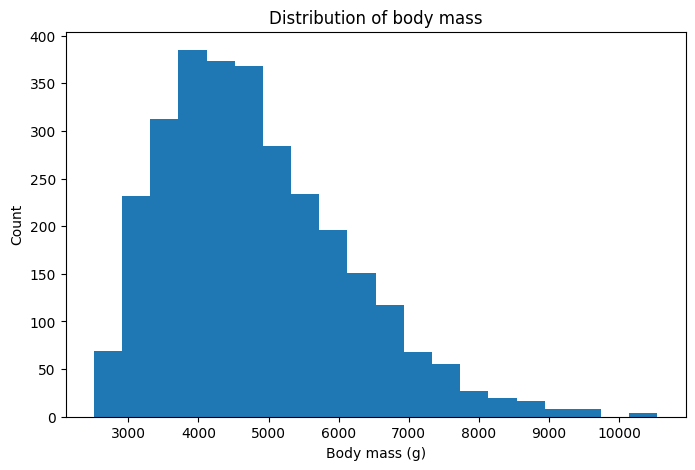

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(df["body_mass_g"], bins=20)
plt.title("Distribution of body mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Count")
plt.show()

## Bar chart of category counts

Bar charts are useful for categorical variables.

Here we count penguins by species.

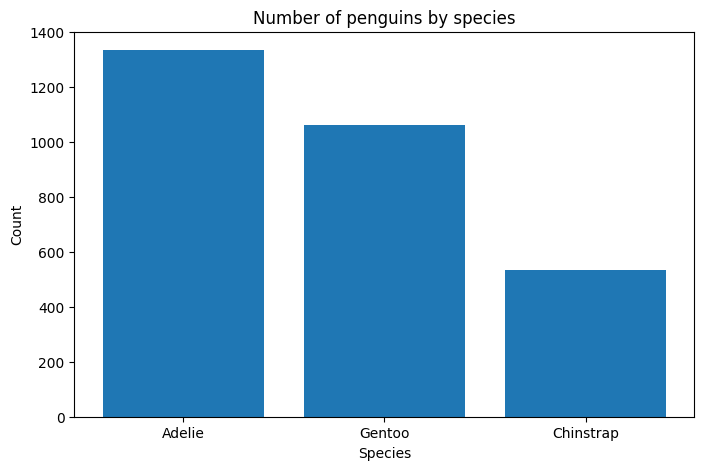

In [34]:
species_counts = df["species"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(species_counts.index, species_counts.values)
plt.title("Number of penguins by species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Scatter plot

A scatter plot shows the relationship between two numeric variables.

Here we compare:
- `flipper_length_mm`
- `body_mass_g`

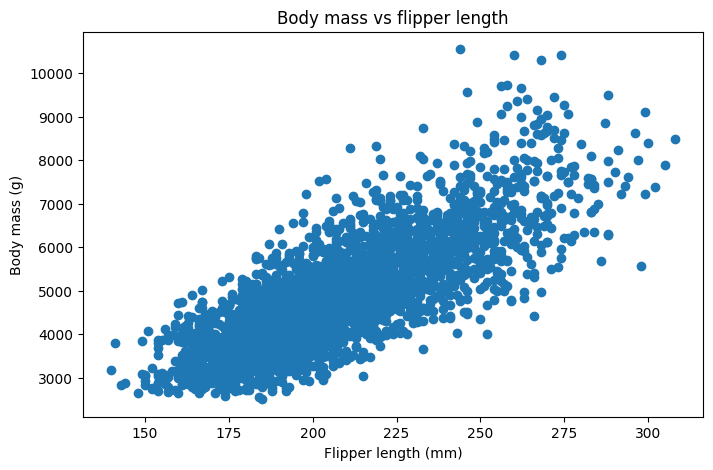

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(df["flipper_length_mm"], df["body_mass_g"])
plt.title("Body mass vs flipper length")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()

## Boxplot

A boxplot helps compare distributions across groups.

Here we compare body mass for the three species.

C:\Users\user\AppData\Local\Temp\ipykernel_27132\1010083392.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=["Adelie", "Chinstrap", "Gentoo"])


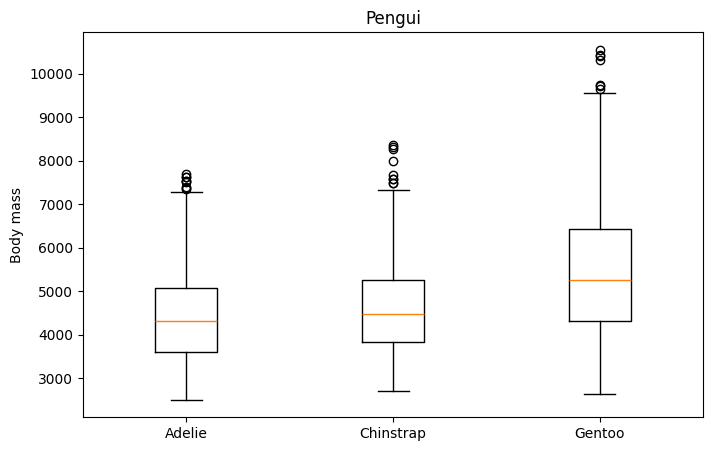

In [36]:
adelie_mass = df[df["species"] == "Adelie"]["body_mass_g"]
chinstrap_mass = df[df["species"] == "Chinstrap"]["body_mass_g"]
gentoo_mass = df[df["species"] == "Gentoo"]["body_mass_g"]

plt.figure(figsize=(8, 5))
data_box=[adelie_mass, chinstrap_mass, gentoo_mass]
plt.boxplot(data_box, labels=["Adelie", "Chinstrap", "Gentoo"])
plt.title("Pengui")
plt.ylabel("Body mass")
plt.show()

Make the following plots:

1. histogram of `bill_length_mm`
2. bar chart of counts for `life_stage`
3. scatter plot of `bill_length_mm` vs `bill_depth_mm`
4. boxplot of `flipper_length_mm` by sex

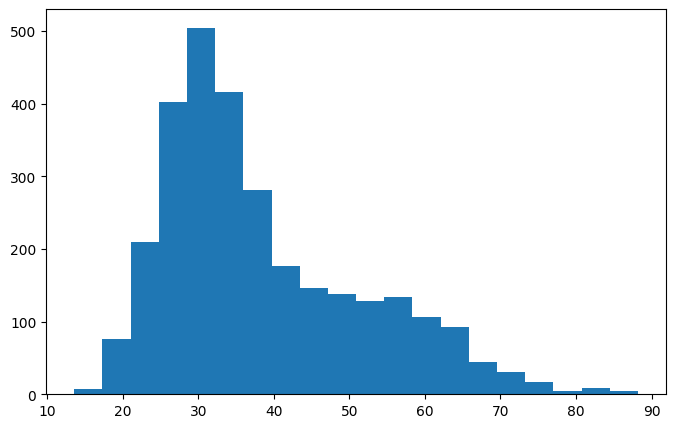

In [37]:
#your code goes here
plt.figure(figsize=(8, 5))
plt.hist(df["bill_length_mm"], bins=20)
plt.show()

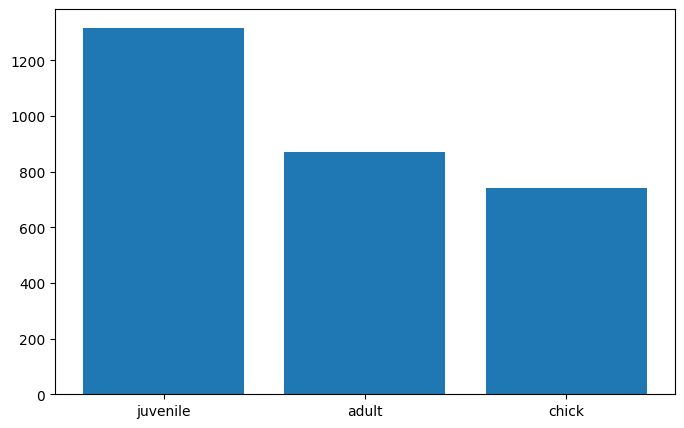

In [38]:
#your code goes here

life_stage_counts = df["life_stage"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(life_stage_counts.index, life_stage_counts.values)
plt.show()

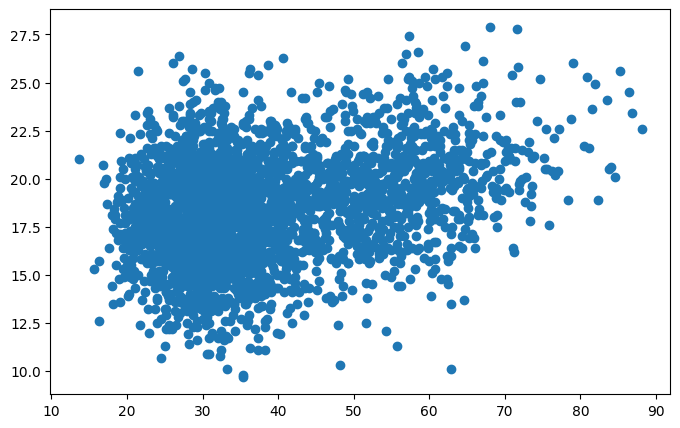

In [39]:
#your code goes here

plt.figure(figsize=(8, 5))
plt.scatter(df["bill_length_mm"], df["bill_depth_mm"])
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_27132\3350561529.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_flipper, male_flipper], labels=["female", "male"])


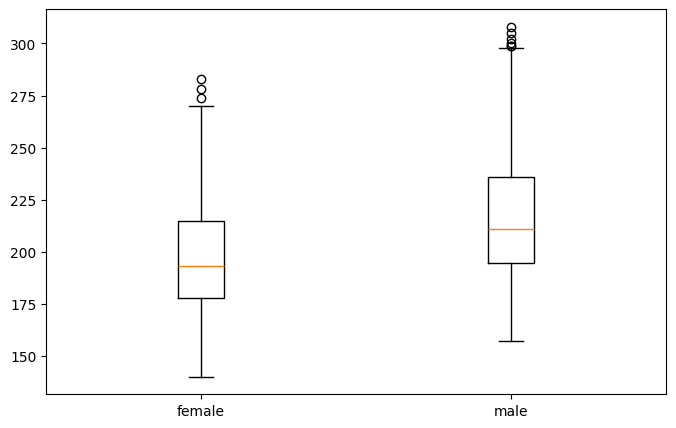

In [40]:
#your code goes here

female_flipper = df[df["sex"] == "female"]["flipper_length_mm"]
male_flipper = df[df["sex"] == "male"]["flipper_length_mm"]

plt.figure(figsize=(8, 5))
plt.boxplot([female_flipper, male_flipper], labels=["female", "male"])
plt.show()

# Correlation

Corelation measure the strength and direction of a linear(and non-linear) relationship between two numeric variables. / Кореляція вимірює сили та напрямок лінійного та нелінійного зв'язку між двома змінними

The correlation coefficient is usually written as **r**.

Its values are between **-1** and **1**.

- close to `1` strong positive relationship
- close to `-1` strong negative relationship
- close to `0`  weak or no linear relationship


In [41]:
df["body_mass_g"].corr(df["flipper_length_mm"])

0.7941249625791258

How to work - with non-linear relationship - **Spearman** correlation(but first normality test) / Як працювати з нелінійною кореляцією - використовувати кореляцію **Спірмана**, перед тим перевіривши номральність

In [42]:
stat, p_value = shapiro(df["body_mass_g"])

print("Shapiro test statistic:", stat)
print("p-value:", p_value)

Shapiro test statistic: 0.9541203967166159
p-value: 2.0838821623488944e-29


If our **pvalue <0.05** we can assume non-normality, in this case lets use Spearman correlation

In [43]:
num_df = df[[
    "bill_length_mm",
    "bill_depth_mm",
]].dropna()

corr_spearman = num_df.corr(method="spearman")

print("\nSpearman correlation:\n", corr_spearman)



Spearman correlation:
                 bill_length_mm  bill_depth_mm
bill_length_mm        1.000000       0.263487
bill_depth_mm         0.263487       1.000000


Calculate Spearman and Pearson correlation for body mass and flippers lenght

In [44]:
#your code goes here
num_df = df[[
    "body_mass_g",
    "flipper_length_mm",
]].dropna()

corr_spearman = num_df.corr(method="spearman")

print("\nSpearman correlation:\n", corr_spearman)



Spearman correlation:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.792007
flipper_length_mm     0.792007           1.000000


## Correlation matrix

A correlation matrix shows pairwise correlations for several numeric variables at once. We can make a table out of it.

In [45]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "year"]
df[numeric_cols].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,0.309348,0.669156,0.661494,0.007161
bill_depth_mm,0.309348,1.000000,0.484506,0.559335,-0.019208
flipper_length_mm,0.669156,0.484506,1.000000,0.794125,0.002910
body_mass_g,0.661494,0.559335,0.794125,1.000000,-0.001642
year,0.007161,-0.019208,0.002910,-0.001642,1.000000


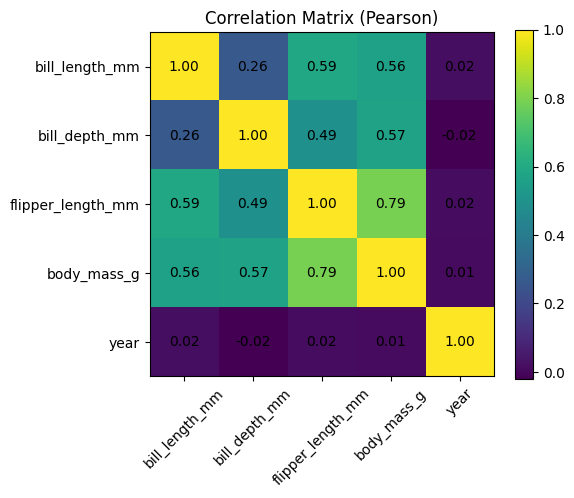

In [46]:
corr = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Correlation Matrix (Pearson)")
plt.tight_layout()
plt.show()

Not all python libraries are made equal - **seaborn** provide much faster and easier way to do same plot

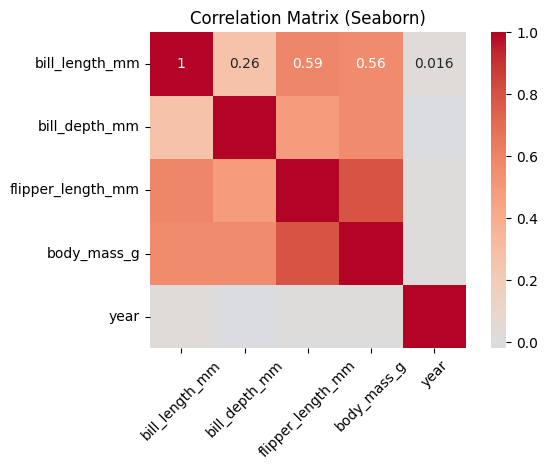

In [47]:
import seaborn as sns
num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
corr = num_df.corr(method="spearman")


sns.heatmap(
    corr,
    annot=corr.values,
    cmap="coolwarm",
    center=0,
    square=True)

plt.title("Correlation Matrix (Seaborn)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
corr.values

array([[ 1.        ,  0.26348741,  0.58696801,  0.56172155,  0.01575469],
       [ 0.26348741,  1.        ,  0.49165868,  0.56777196, -0.02011918],
       [ 0.58696801,  0.49165868,  1.        ,  0.79200685,  0.01506566],
       [ 0.56172155,  0.56777196,  0.79200685,  1.        ,  0.00958891],
       [ 0.01575469, -0.02011918,  0.01506566,  0.00958891,  1.        ]])

# t-test

A t-test compares the means of two groups. / Т-тест потрібен для порівняння двох груп.

We need:
- one numeric variable
- one grouping variable with two groups

Do adult male and adult female penguins differ in average body mass?

In [49]:
adult = df[df["life_stage"] == "adult"]

male_mass = adult[adult["sex"] == "male"]["body_mass_g"]
female_mass = adult[adult["sex"] == "female"]["body_mass_g"]

male_mass.describe(), female_mass.describe()

(count      431.000000
 mean      6564.786543
 std       1300.619062
 min       3655.000000
 25%       5537.000000
 50%       6427.000000
 75%       7453.500000
 max      10549.000000
 Name: body_mass_g, dtype: float64,
 count     440.000000
 mean     5415.415909
 std       955.510252
 min      3218.000000
 25%      4659.250000
 50%      5348.500000
 75%      6076.000000
 max      8055.000000
 Name: body_mass_g, dtype: float64)

## Hypotheses of the t-test

- **Null hypothesis (H0):** the mean body mass is the same in adult males and adult females
- **Alternative hypothesis (H1):** the mean body mass is different

We will use Welch's t-test by setting `equal_var=False`. 

In [50]:
ttest_result = stats.ttest_ind(male_mass, female_mass, equal_var=False)
ttest_result

TtestResult(statistic=14.838498164877878, pvalue=4.108958635162739e-44, df=788.8789235368548)

## Interpreting the result

The output gives:
- a t statistic
- a p-value

If the p-value is small, we reject the null hypothesis.

A common threshold is **0.05**.

- if `p < 0.05`: evidence of a difference
- if `p >= 0.05`: not enough evidence of a difference

Run a t-test to compare `bill_length_mm` between male and female adult penguins.

Steps:
1. filter only adults
2. split bill length into male and female groups
3. run stats.ttest_ind
4. compare the means

In [51]:
#your code goes here
adult = df[df["life_stage"] == "adult"]

male_bill = adult[adult["sex"] == "male"]["bill_length_mm"]
female_bill = adult[adult["sex"] == "female"]["bill_length_mm"]

stats.ttest_ind(male_bill, female_bill, equal_var=False)

TtestResult(statistic=4.896682522834034, pvalue=1.1710682675612943e-06, df=831.648028336613)

In [52]:
male_bill.mean(), female_bill.mean()

(48.40162412993039, 43.465454545454556)

# One-way ANOVA

ANOVA stands for **Analysis of Variance**. It is needed to compare more than 2 groups.

**Do adult penguin species differ in average flipper length?**

In [53]:
adult = df[df["life_stage"] == "adult"]

adelie_flipper = adult[adult["species"] == "Adelie"]["flipper_length_mm"]
chinstrap_flipper = adult[adult["species"] == "Chinstrap"]["flipper_length_mm"]
gentoo_flipper = adult[adult["species"] == "Gentoo"]["flipper_length_mm"]

adult.groupby("species")["flipper_length_mm"].mean()

species
Adelie       225.377660
Chinstrap    223.855172
Gentoo       242.611429
Name: flipper_length_mm, dtype: float64

In [54]:
anova_result = stats.f_oneway(adelie_flipper, chinstrap_flipper, gentoo_flipper)
anova_result

F_onewayResult(statistic=53.01773072555656, pvalue=1.8884749845794826e-22)

## Hypotheses for ANOVA

- **Null hypothesis (H0):** all group means are equal
- **Alternative hypothesis (H1):** at least one group mean is different

If the p-value is below 0.05, we conclude that not all means are equal.

## Important ANOVA note

ANOVA tells us that a difference exists somewhere among the groups.  
It does **not** automatically tell us exactly which pairs differ.
To get whihc groups differs we need to run post-hoc test  - TukeyHSD.

In [55]:

anova_data = df[["species", "flipper_length_mm"]].dropna()

tukey = pairwise_tukeyhsd(
    endog=anova_data["flipper_length_mm"],  
    groups=anova_data["species"],  
    alpha=0.05)

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
   Adelie Chinstrap   2.4376 0.1992  -0.893  5.7682  False
   Adelie    Gentoo  17.4419    0.0 14.7697 20.1142   True
Chinstrap    Gentoo  15.0043    0.0 11.5547  18.454   True
----------------------------------------------------------


Use one-way ANOVA to test whether mean ``body mass`` differs among the three ``species``.

Steps:
1. filter to adults
2. create three groups
3. run stats.f_oneway
4. run post hoc test

In [56]:
#your code goes here
adult = df[df["life_stage"] == "adult"]

adelie_mass_adult = adult[adult["species"] == "Adelie"]["body_mass_g"]
chinstrap_mass_adult = adult[adult["species"] == "Chinstrap"]["body_mass_g"]
gentoo_mass_adult = adult[adult["species"] == "Gentoo"]["body_mass_g"]

adult.groupby("species")["body_mass_g"].mean()

species
Adelie       5349.250000
Chinstrap    5624.358621
Gentoo       6815.302857
Name: body_mass_g, dtype: float64

# Simple linear regression

Linear regression models the relationship between:

- one predictor variable `X`
- one or more outcome variable `y`

We will predict:

- `body_mass_g` from `flipper_length_mm`

This is called **simple linear regression** because there is only one predictor.

## The general idea

The model tries to find a line:

`predicted body mass = intercept + slope × flipper length`

- the **intercept** is where the line starts
- the **slope** tells us how much the predicted outcome changes when the predictor increases by 1 unit

In [57]:
X = df[["flipper_length_mm"]]
y = df["body_mass_g"]

model = LinearRegression()
model.fit(X, y)

LinearRegression()

## Model coefficients

In [58]:
model.coef_, model.intercept_

(array([36.11123201]), -2644.752767467917)

### Interpretation

If the slope is positive, then larger flipper length is associated with larger predicted body mass.

## R-squared

`R^2` tells us how much variation in the outcome is explained by the predictor.

- closer to 1 means stronger explanatory power
- closer to 0 means weaker explanatory power

In [59]:
model.score(X, y)

0.6306344561912979

## Make predictions

We can ask the model to predict body mass for given flipper lengths.

In [60]:
new_penguins = pd.DataFrame({"flipper_length_mm": [180, 190, 200, 210, 220]})
model.predict(new_penguins)

array([3855.26899361, 4216.38131367, 4577.49363373, 4938.60595379,
       5299.71827385])

## Plot the regression line

We will:
1. draw the scatter plot
2. create predicted values
3. draw a line through those predictions

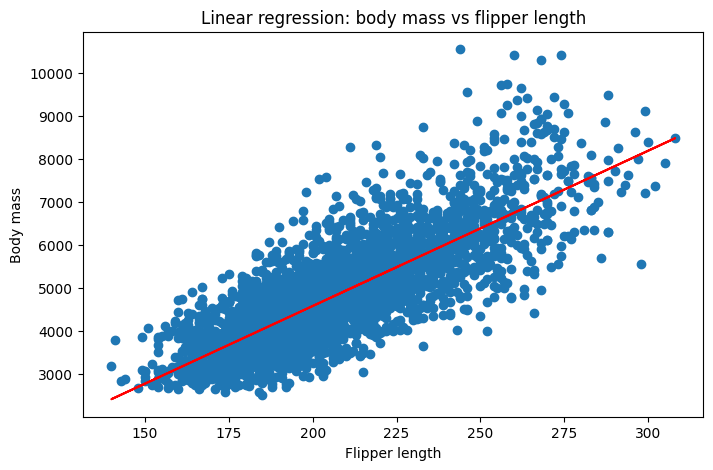

In [61]:
predicted_y = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X["flipper_length_mm"], y)
plt.plot(X["flipper_length_mm"], predicted_y, color="red")
plt.title("Linear regression: body mass vs flipper length")
plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.show()

Fit a linear regression model to predict `bill_depth_mm` from `body_mass_g`.

Tasks:
1. create `X` from `bill_length_mm`
2. create `y` from `body_mass_g`
3. fit a `LinearRegression()` model
4. print the slope, intercept, and `R^2`

In [62]:
#your code goes here
X2 = df[["bill_length_mm"]]
y2 = df["body_mass_g"]

model2 = LinearRegression()
model2.fit(X2, y2)

print("Slope:", model2.coef_[0])
print("Intercept:", model2.intercept_)
print("R^2:", model2.score(X2, y2))

Slope: 65.87989281229146
Intercept: 2291.568076037521
R^2: 0.43757484809147296


Linear regression can include more than 1 variable,  it is called ``Multiple Linear Regression``

General formula would look like  ``predicted body mass = intercept + slope1 × flipper length + slope2 × bill length + slope3 × bill depth``

In [90]:
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]]
y = df["body_mass_g"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: -3018.9193615379054
Coefficients: [ 24.08726911 110.26091274  23.62222943]


In [91]:
model.score(X, y)

0.7027463941963971

### Feature scaling (normalization)

In regression, different features may have very different scales:

- body_mass_g in thousands units - g
- bill_length_mm in tens units - mm

This can affect:
- interpretation of coefficients
- numerical stability of models

Two common approaches:

1. **Standardization (Z-score)**  
   transforms data to mean = 0, std = 1

2. **Min-Max scaling**  
   scales data between 0 and 1

In [85]:
df[[
    "bill_length_mm",
    "flipper_length_mm",
    "body_mass_g"]].dropna().describe()



,bill_length_mm,flipper_length_mm,body_mass_g
count,2930.000000,2930.000000,2930.000000
mean,38.460137,206.862799,4825.317747
std,13.181151,28.868658,1312.744023
min,13.600000,140.000000,2508.000000
25%,28.800000,185.000000,3845.000000
50%,34.450000,203.000000,4618.500000
75%,46.500000,225.000000,5594.000000
max,88.200000,308.000000,10549.000000


In [87]:
data_sc= df[[
    "bill_length_mm", 
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"]].dropna()

X = data_sc.drop(columns=["body_mass_g"])
y = data_sc["body_mass_g"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm
0,1.308141,-0.657569,0.663019
1,-0.034915,-1.018383,0.489791
2,1.687535,-0.188510,-1.034613
3,-0.209436,-0.585406,-0.445639
4,1.710299,0.857852,0.143336


In [88]:
model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)

print("R²:", model_scaled.score(X_scaled, y))

R²: 0.7027463941963971


In [92]:
print("Original coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.2f}")

print("\nScaled coefficients:")
for name, coef in zip(X.columns, model_scaled.coef_):
    print(f"{name}: {coef:.2f}")

Original coefficients:
bill_length_mm: 24.09
bill_depth_mm: 110.26
flipper_length_mm: 23.62

Scaled coefficients:
bill_length_mm: 317.44
bill_depth_mm: 305.59
flipper_length_mm: 681.83


Regression can include not only numerical, but also a ``categorical`` features
To add them to our model they must be converted into numerical form.

One common method is **one-hot encoding**:
- each category becomes a separate column
- values are 0 or 1


In [65]:

data = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "species", "body_mass_g"]]

data_encoded = pd.get_dummies(data,  columns=["species"], drop_first=True)
data_encoded

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo
2,55.7,16.6,226.0,5388.0,0,0
3,38.0,15.6,221.0,6262.0,0,0
4,60.7,17.9,177.0,4811.0,0,0
5,35.7,16.8,194.0,5266.0,0,0
6,61.0,20.8,211.0,5961.0,0,0
...,...,...,...,...,...,...
3425,44.0,20.4,252.0,6447.0,0,1
3426,54.5,25.2,245.0,6872.0,0,1
3427,51.4,20.4,258.0,7409.0,0,1
3428,55.9,20.5,247.0,6491.0,0,1


In [66]:
X = data_encoded.drop(columns=["body_mass_g"])
y = data_encoded["body_mass_g"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.2f}")

Intercept: -2869.670013264973
bill_length_mm: 22.30
bill_depth_mm: 100.31
flipper_length_mm: 23.72
species_Chinstrap: 43.98
species_Gentoo: 204.82


In [67]:
model.score(X, y)

0.7069472423820946

First technique to try - scaling

## Polynomial regression on synthetic data

In real datasets relationships are not always perfectly linear.

To understand polynomial regression clearly, we will first create some synthetic non-linear data

In [69]:
np.random.seed(2026)
x = np.linspace(0, 10, 80)
y = 3 + 2 * x + 2 * x**2 + np.random.normal(0, 8, size=len(x))


poly_df = pd.DataFrame({"x": x, "y": y})

poly_df.head()

,x,y
0,0.000000,-0.453748
1,0.126582,-7.857781
2,0.253165,6.127079
3,0.379747,3.942030
4,0.506329,16.123058


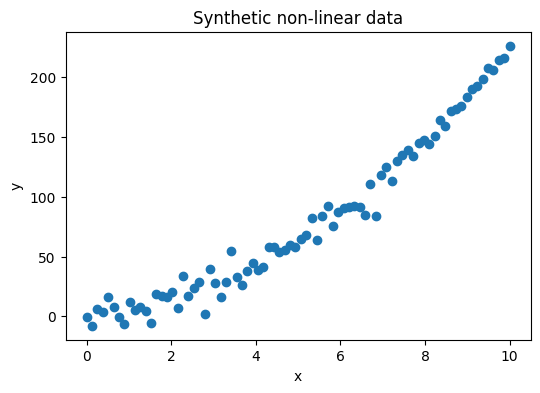

In [70]:
plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic non-linear data")
plt.show()

In [71]:
X = poly_df[["x"]]
y = poly_df["y"]

linear_model = LinearRegression()
linear_model.fit(X, y)

print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_[0])
print("R:", linear_model.score(X, y))

Intercept: -30.895507948988225
Coefficient: 22.140845493977213
R: 0.9342805753690181


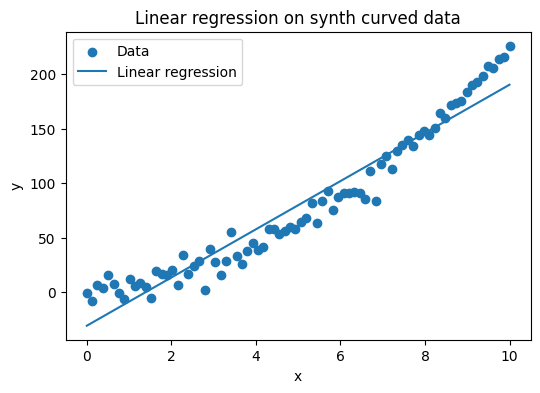

In [72]:
y_pred_linear = linear_model.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"], label="Data")
plt.plot(poly_df["x"], y_pred_linear, label="Linear regression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression on synth curved data")
plt.legend()
plt.show()

In [73]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_poly

array([[0.00000000e+00, 0.00000000e+00],
       [1.26582278e-01, 1.60230732e-02],
       [2.53164557e-01, 6.40922929e-02],
       [3.79746835e-01, 1.44207659e-01],
       [5.06329114e-01, 2.56369172e-01],
       [6.32911392e-01, 4.00576831e-01],
       [7.59493671e-01, 5.76830636e-01],
       [8.86075949e-01, 7.85130588e-01],
       [1.01265823e+00, 1.02547669e+00],
       [1.13924051e+00, 1.29786893e+00],
       [1.26582278e+00, 1.60230732e+00],
       [1.39240506e+00, 1.93879186e+00],
       [1.51898734e+00, 2.30732254e+00],
       [1.64556962e+00, 2.70789938e+00],
       [1.77215190e+00, 3.14052235e+00],
       [1.89873418e+00, 3.60519148e+00],
       [2.02531646e+00, 4.10190675e+00],
       [2.15189873e+00, 4.63066816e+00],
       [2.27848101e+00, 5.19147573e+00],
       [2.40506329e+00, 5.78432943e+00],
       [2.53164557e+00, 6.40922929e+00],
       [2.65822785e+00, 7.06617529e+00],
       [2.78481013e+00, 7.75516744e+00],
       [2.91139241e+00, 8.47620574e+00],
       [3.037974

In [74]:
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)
print("R:", poly_model.score(X_poly, y))

Intercept: 1.9294097565069421
Coefficients: [2.1933955 1.994745 ]
R: 0.9860921391326527


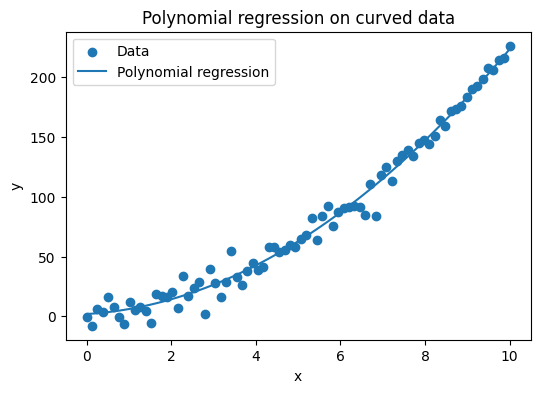

In [75]:
y_pred_poly = poly_model.predict(X_poly)

plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"], label="Data")
plt.plot(poly_df["x"], y_pred_poly, label="Polynomial regression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial regression on curved data")
plt.legend()
plt.show()

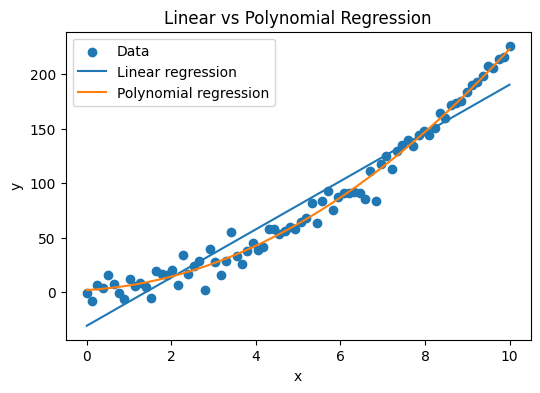

In [76]:
plt.figure(figsize=(6, 4))
plt.scatter(poly_df["x"], poly_df["y"], label="Data")
plt.plot(poly_df["x"], y_pred_linear, label="Linear regression")
plt.plot(poly_df["x"], y_pred_poly, label="Polynomial regression")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

Competition - now you will try to build a model yourself with the best possible R.
Hints:
- include additional features
- exclude some features
- try different poly transformations and their degrees
- try preprocess your data
- Get back to NA treatment
- all of the above